https://github.com/aashutosh-raut/Carprediction

In [346]:
import mlflow

mlflow.set_tracking_uri("http://localhost:9000") 
mlflow.set_experiment(experiment_name="experimentA2_7")

<Experiment: artifact_location='mlflow-artifacts:/688322752433676532', creation_time=1757702480828, experiment_id='688322752433676532', last_update_time=1757702480828, lifecycle_stage='active', name='experimentA2_7', tags={}>

In [347]:
import numpy as np #importing the necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [348]:
import matplotlib
np.__version__, pd.__version__, sns.__version__, matplotlib.__version__

('2.1.3', '2.2.3', '0.13.2', '3.10.0')

In [349]:
df = pd.read_csv('Cars.csv') #importing/loading the data set

In [350]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [351]:
df.shape # Checking the number of data and columns

(8128, 13)

In [352]:
df.describe() # here we describe the data, see what the rows and columns have

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [353]:
df.info

<bound method DataFrame.info of                               name  year  selling_price  km_driven    fuel  \
0           Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1     Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2         Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3        Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4           Maruti Swift VXI BSIII  2007         130000     120000  Petrol   
...                            ...   ...            ...        ...     ...   
8123             Hyundai i20 Magna  2013         320000     110000  Petrol   
8124         Hyundai Verna CRDi SX  2007         135000     119000  Diesel   
8125        Maruti Swift Dzire ZDi  2009         382000     120000  Diesel   
8126               Tata Indigo CR4  2013         290000      25000  Diesel   
8127               Tata Indigo CR4  2013         290000      25000  Diesel   

     seller_type transmission  

In [354]:
df.columns # here we see what are the columns (features we will later take to train test the model. some of them we will use some we will drop.) now we will rename the columns below. 

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

In [355]:
df.rename(columns = {'name': 'brand', 'year': 'year', 'selling_price': 'selling_price', 'km_driven': 'km_driven', 'fuel': 'fuel', 'seller_type': 'seller_type', 'transmission': 'transmission', 'owner': 'owner', 'mileage': 'milage',  'engine': 'engine', 'max_power': 'max_power', 'torque': 'torque', 'seats': 'seats'}, inplace = True)
# The above is the renaming process of the Exploratory (EDA)

In [356]:
df.columns # checking the updated columns names

Index(['brand', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'milage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

In [357]:
df['owner'].unique() # checking the data in the owner column

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], dtype=object)

In [358]:
df['owner'] = df['owner'].replace({
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
}) # changing the string into numeric values

C:\Users\aashu\AppData\Local\Temp\ipykernel_24276\3554053464.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['owner'] = df['owner'].replace({


In [359]:
df['owner'].unique() # checking the updated data 

array([1, 2, 3, 4, 5])

In [360]:
df

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,milage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,1,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,2,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,3,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,1,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,1,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,1,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,4,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,1,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,1,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


In [361]:
df['fuel'].unique() # checking the data in the fuel column 

array(['Diesel', 'Petrol', 'LPG', 'CNG'], dtype=object)

In [362]:
df = df[df['fuel'] != 'LPG']
df['fuel'] #droping LPG from the data

0       Diesel
1       Diesel
2       Petrol
3       Diesel
4       Petrol
         ...  
8123    Petrol
8124    Diesel
8125    Diesel
8126    Diesel
8127    Diesel
Name: fuel, Length: 8090, dtype: object

In [363]:
df['fuel'].unique()

array(['Diesel', 'Petrol', 'CNG'], dtype=object)

In [364]:
df = df[df['fuel'] != 'CNG']
df['fuel'] #dropping CNG from the data

0       Diesel
1       Diesel
2       Petrol
3       Diesel
4       Petrol
         ...  
8123    Petrol
8124    Diesel
8125    Diesel
8126    Diesel
8127    Diesel
Name: fuel, Length: 8033, dtype: object

In [365]:
df['fuel'].unique() # checking if LPG and CNG have been dropped from the data

array(['Diesel', 'Petrol'], dtype=object)

In [366]:
df['milage'].unique()

array(['23.4 kmpl', '21.14 kmpl', '17.7 kmpl', '23.0 kmpl', '16.1 kmpl',
       '20.14 kmpl', '23.59 kmpl', '20.0 kmpl', '19.01 kmpl', '17.3 kmpl',
       '19.3 kmpl', nan, '18.9 kmpl', '18.15 kmpl', '24.52 kmpl',
       '19.7 kmpl', '22.54 kmpl', '21.0 kmpl', '25.5 kmpl', '26.59 kmpl',
       '21.5 kmpl', '20.3 kmpl', '21.4 kmpl', '24.7 kmpl', '18.2 kmpl',
       '16.8 kmpl', '24.3 kmpl', '14.0 kmpl', '18.6 kmpl', '23.95 kmpl',
       '17.0 kmpl', '20.63 kmpl', '13.93 kmpl', '16.0 kmpl', '17.8 kmpl',
       '18.5 kmpl', '12.55 kmpl', '12.99 kmpl', '14.8 kmpl', '13.5 kmpl',
       '26.0 kmpl', '20.65 kmpl', '27.3 kmpl', '11.36 kmpl', '17.68 kmpl',
       '14.28 kmpl', '18.53 kmpl', '14.84 kmpl', '21.12 kmpl',
       '20.36 kmpl', '21.27 kmpl', '18.16 kmpl', '22.0 kmpl', '25.1 kmpl',
       '20.51 kmpl', '21.66 kmpl', '25.2 kmpl', '22.9 kmpl', '16.02 kmpl',
       '20.54 kmpl', '22.77 kmpl', '15.71 kmpl', '23.1 kmpl',
       '19.02 kmpl', '19.81 kmpl', '16.47 kmpl', '15.04 kmpl',
      

In [367]:
df['milage'] = df['milage'].str.split(' ').str[0]
df['milage']

0        23.4
1       21.14
2        17.7
3        23.0
4        16.1
        ...  
8123     18.5
8124     16.8
8125     19.3
8126    23.57
8127    23.57
Name: milage, Length: 8033, dtype: object

In [368]:
df['milage'].dtype

dtype('O')

In [369]:
df['milage'] = df['milage'].astype(float)
df['milage'].dtype

dtype('float64')

In [370]:
df['engine'].unique()

array(['1248 CC', '1498 CC', '1497 CC', '1396 CC', '1298 CC', '1197 CC',
       '796 CC', '1364 CC', '1399 CC', '1461 CC', '993 CC', nan,
       '1061 CC', '1198 CC', '1199 CC', '998 CC', '1591 CC', '2179 CC',
       '1368 CC', '2982 CC', '2494 CC', '2143 CC', '2477 CC', '1462 CC',
       '2755 CC', '1968 CC', '1798 CC', '1196 CC', '1373 CC', '1598 CC',
       '1998 CC', '1086 CC', '1194 CC', '1172 CC', '1405 CC', '1582 CC',
       '999 CC', '2487 CC', '1999 CC', '3604 CC', '2987 CC', '1995 CC',
       '1451 CC', '1969 CC', '2967 CC', '2497 CC', '1797 CC', '1991 CC',
       '2362 CC', '1493 CC', '1599 CC', '1341 CC', '1794 CC', '799 CC',
       '1193 CC', '2696 CC', '1495 CC', '1186 CC', '1047 CC', '2498 CC',
       '2956 CC', '2523 CC', '1120 CC', '624 CC', '1496 CC', '1984 CC',
       '2354 CC', '814 CC', '793 CC', '1799 CC', '936 CC', '1956 CC',
       '1997 CC', '1499 CC', '1948 CC', '2997 CC', '2489 CC', '2499 CC',
       '2609 CC', '2953 CC', '1150 CC', '1994 CC', '1388 CC', '152

In [371]:
df['engine'] = df['engine'].str.split(' ').str[0]
df['engine']

0       1248
1       1498
2       1497
3       1396
4       1298
        ... 
8123    1197
8124    1493
8125    1248
8126    1396
8127    1396
Name: engine, Length: 8033, dtype: object

In [372]:
df['engine'] = df['engine'].astype(float)
df['engine'].dtype

dtype('float64')

In [373]:
df['max_power']

0           74 bhp
1       103.52 bhp
2           78 bhp
3           90 bhp
4         88.2 bhp
           ...    
8123     82.85 bhp
8124       110 bhp
8125      73.9 bhp
8126        70 bhp
8127        70 bhp
Name: max_power, Length: 8033, dtype: object

In [374]:
df['max_power'] = df['max_power'].str.split(' ').str[0]
df['max_power']

0           74
1       103.52
2           78
3           90
4         88.2
         ...  
8123     82.85
8124       110
8125      73.9
8126        70
8127        70
Name: max_power, Length: 8033, dtype: object

In [375]:
df['max_power'] = df['max_power'].astype(float)
df['max_power'].dtype

dtype('float64')

In [376]:
df['brand']

0             Maruti Swift Dzire VDI
1       Skoda Rapid 1.5 TDI Ambition
2           Honda City 2017-2020 EXi
3          Hyundai i20 Sportz Diesel
4             Maruti Swift VXI BSIII
                    ...             
8123               Hyundai i20 Magna
8124           Hyundai Verna CRDi SX
8125          Maruti Swift Dzire ZDi
8126                 Tata Indigo CR4
8127                 Tata Indigo CR4
Name: brand, Length: 8033, dtype: object

In [377]:
df['brand'] = df['brand'].str.split(' ').str[0]
df['brand']

0        Maruti
1         Skoda
2         Honda
3       Hyundai
4        Maruti
         ...   
8123    Hyundai
8124    Hyundai
8125     Maruti
8126       Tata
8127       Tata
Name: brand, Length: 8033, dtype: object

In [378]:
df.drop(columns={'torque'}, inplace=True) #Dropping torque 

In [379]:
df

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,milage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,2013,320000,110000,Petrol,Individual,Manual,1,18.50,1197.0,82.85,5.0
8124,Hyundai,2007,135000,119000,Diesel,Individual,Manual,4,16.80,1493.0,110.00,5.0
8125,Maruti,2009,382000,120000,Diesel,Individual,Manual,1,19.30,1248.0,73.90,5.0
8126,Tata,2013,290000,25000,Diesel,Individual,Manual,1,23.57,1396.0,70.00,5.0


In [380]:
df['owner'].unique()

array([1, 2, 3, 4, 5])

In [381]:
df['owner'].dtype

dtype('int64')

In [382]:
df = df[df['owner'] !=5] # Removing test drive cars
df['owner'].unique()

array([1, 2, 3, 4])

In [383]:
df['selling_price']

0       450000
1       370000
2       158000
3       225000
4       130000
         ...  
8123    320000
8124    135000
8125    382000
8126    290000
8127    290000
Name: selling_price, Length: 8028, dtype: int64

In [384]:
y = np.log(df['selling_price']) #Transforming y ie selling price using log

y

0       13.017003
1       12.821258
2       11.970350
3       12.323856
4       11.775290
          ...    
8123    12.676076
8124    11.813030
8125    12.853176
8126    12.577636
8127    12.577636
Name: selling_price, Length: 8028, dtype: float64

In [385]:
df.head()

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,milage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0


<Axes: xlabel='owner', ylabel='count'>

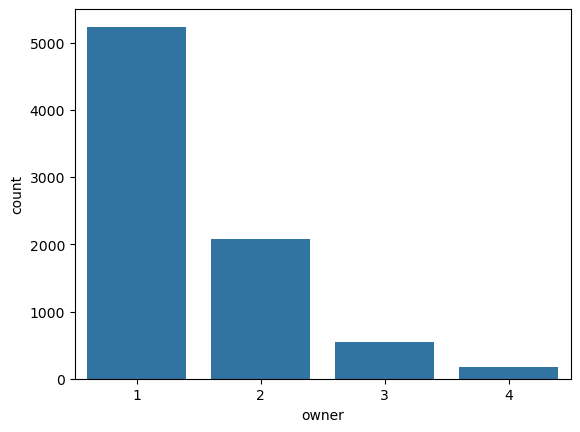

In [386]:
sns.countplot(data = df, x = 'owner') # Univariate analysis. Countplot.

<Axes: xlabel='fuel', ylabel='count'>

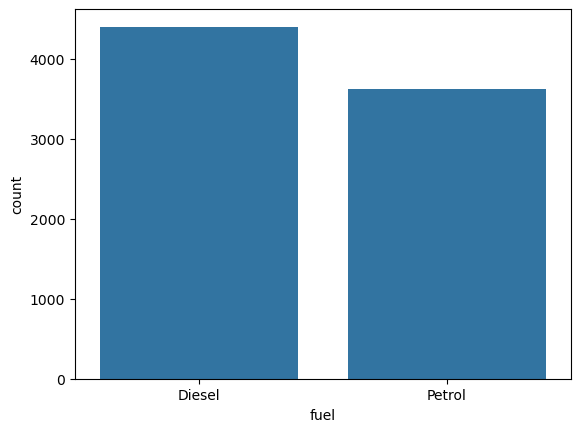

In [387]:
sns.countplot(data = df, x = 'fuel')

<Axes: xlabel='transmission', ylabel='count'>

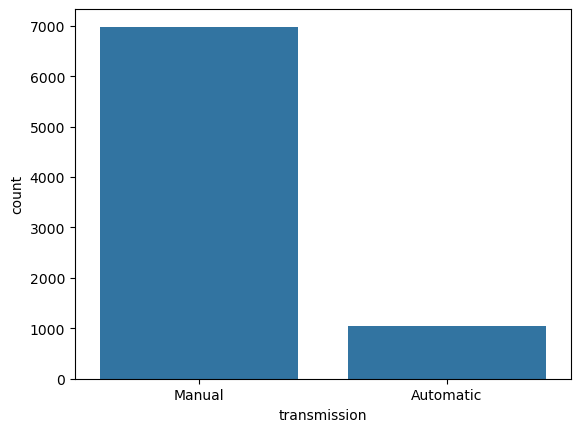

In [388]:
sns.countplot(data = df, x = 'transmission')

<Axes: xlabel='seats', ylabel='count'>

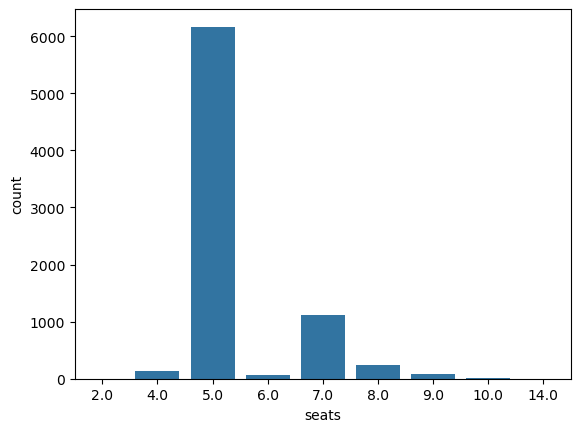

In [389]:
sns.countplot(data = df, x = 'seats')

Text(0.5, 0, 'engine')

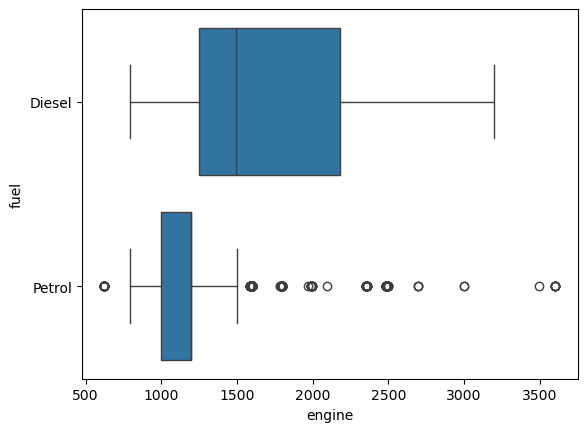

In [390]:
sns.boxplot(x = df["engine"], y = df["fuel"]); #Boxplot
plt.ylabel("fuel")
plt.xlabel("engine")

<Axes: xlabel='milage', ylabel='engine'>

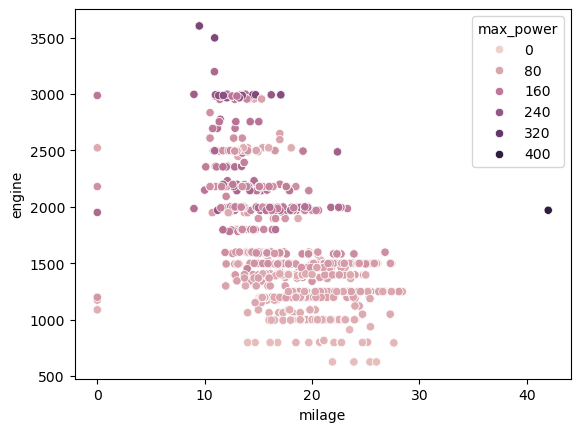

In [391]:

sns.scatterplot(x = df['milage'], y = df['engine'], hue=df['max_power']) #scatterplot

<Axes: xlabel='milage', ylabel='year'>

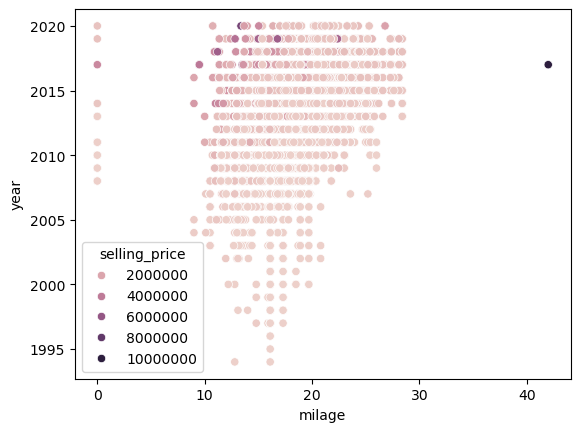

In [392]:

sns.scatterplot(x = df['milage'], y = df['year'], hue=df['selling_price'])

In [393]:
df

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,milage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,2013,320000,110000,Petrol,Individual,Manual,1,18.50,1197.0,82.85,5.0
8124,Hyundai,2007,135000,119000,Diesel,Individual,Manual,4,16.80,1493.0,110.00,5.0
8125,Maruti,2009,382000,120000,Diesel,Individual,Manual,1,19.30,1248.0,73.90,5.0
8126,Tata,2013,290000,25000,Diesel,Individual,Manual,1,23.57,1396.0,70.00,5.0


In [394]:
print(df['fuel'].unique())
print(df['brand'].unique())
print(df['transmission'].unique())



['Diesel' 'Petrol']
['Maruti' 'Skoda' 'Honda' 'Hyundai' 'Toyota' 'Ford' 'Renault' 'Mahindra'
 'Tata' 'Chevrolet' 'Fiat' 'Datsun' 'Jeep' 'Mercedes-Benz' 'Mitsubishi'
 'Audi' 'Volkswagen' 'BMW' 'Nissan' 'Lexus' 'Jaguar' 'Land' 'MG' 'Volvo'
 'Daewoo' 'Kia' 'Force' 'Ambassador' 'Ashok' 'Isuzu' 'Opel' 'Peugeot']
['Manual' 'Automatic']


In [395]:
df.dtypes #checking datatypes

brand             object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner              int64
milage           float64
engine           float64
max_power        float64
seats            float64
dtype: object

In [396]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["fuel"] = le.fit_transform(df["fuel"])

df["fuel"].unique()
 # 0 = diesel and 1 = petrol 
 # transforming object 

C:\Users\aashu\AppData\Local\Temp\ipykernel_24276\4082662538.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["fuel"] = le.fit_transform(df["fuel"])


array([0, 1])

In [397]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["seller_type"] = le.fit_transform(df["seller_type"])

df["seller_type"].unique() #using fit transform to change object into 1, 0, 2 ie the individual, dealer and trademark dealer

C:\Users\aashu\AppData\Local\Temp\ipykernel_24276\1894372868.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["seller_type"] = le.fit_transform(df["seller_type"])


array([1, 0, 2])

In [398]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["transmission"] = le.fit_transform(df["transmission"])

df["transmission"].unique() 

C:\Users\aashu\AppData\Local\Temp\ipykernel_24276\3588422592.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["transmission"] = le.fit_transform(df["transmission"])


array([1, 0])

In [399]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["brand"] = le.fit_transform(df["brand"])

df["brand"].unique() #assigning brand names of cars with numeric values

C:\Users\aashu\AppData\Local\Temp\ipykernel_24276\3341274267.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["brand"] = le.fit_transform(df["brand"])


array([20, 27, 10, 11, 29,  9, 26, 19, 28,  4,  7,  6, 14, 21, 22,  2, 30,
        3, 23, 17, 13, 16, 18, 31,  5, 15,  8,  0,  1, 12, 24, 25])

<Axes: >

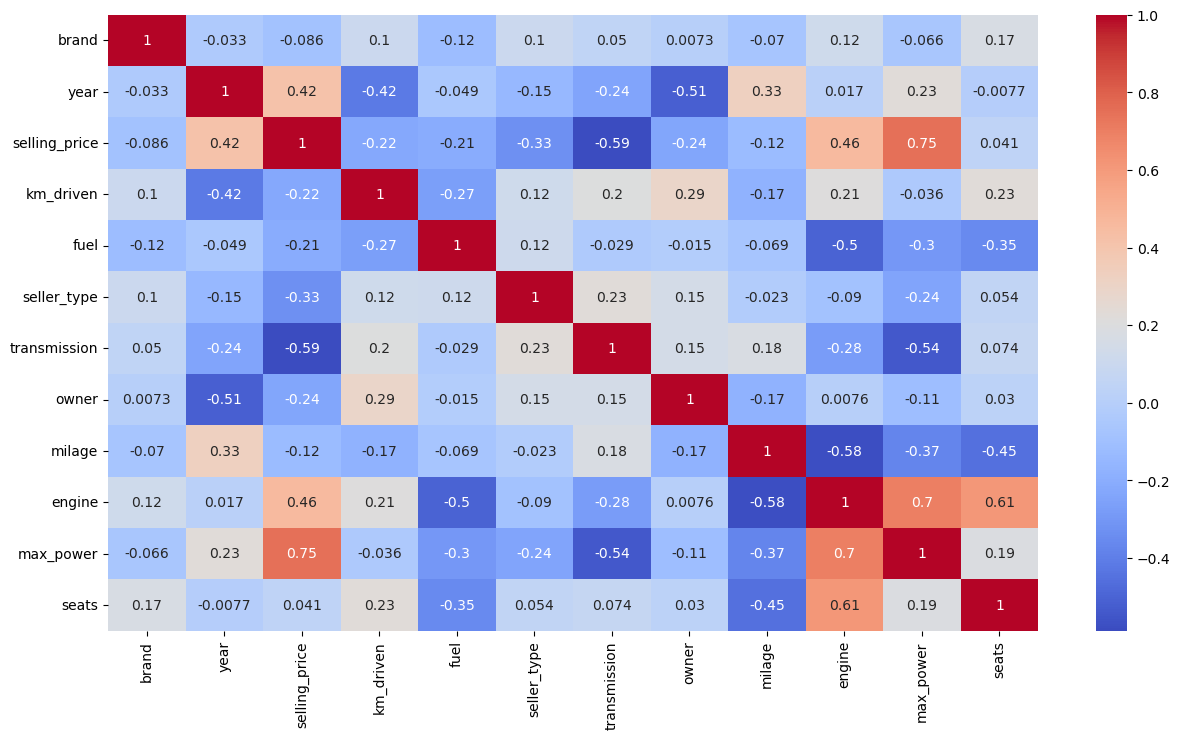

In [400]:
plt.figure(figsize = (15,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm") # plotting the corelation matrix 

In [401]:
df = df.drop(columns=['year', 'transmission', 'owner'])
df # dropping the columns year, transmission and owners

,brand,selling_price,km_driven,fuel,seller_type,milage,engine,max_power,seats
0,20,450000,145500,0,1,23.40,1248.0,74.00,5.0
1,27,370000,120000,0,1,21.14,1498.0,103.52,5.0
2,10,158000,140000,1,1,17.70,1497.0,78.00,5.0
3,11,225000,127000,0,1,23.00,1396.0,90.00,5.0
4,20,130000,120000,1,1,16.10,1298.0,88.20,5.0
...,...,...,...,...,...,...,...,...,...
8123,11,320000,110000,1,1,18.50,1197.0,82.85,5.0
8124,11,135000,119000,0,1,16.80,1493.0,110.00,5.0
8125,20,382000,120000,0,1,19.30,1248.0,73.90,5.0
8126,28,290000,25000,0,1,23.57,1396.0,70.00,5.0


<Axes: >

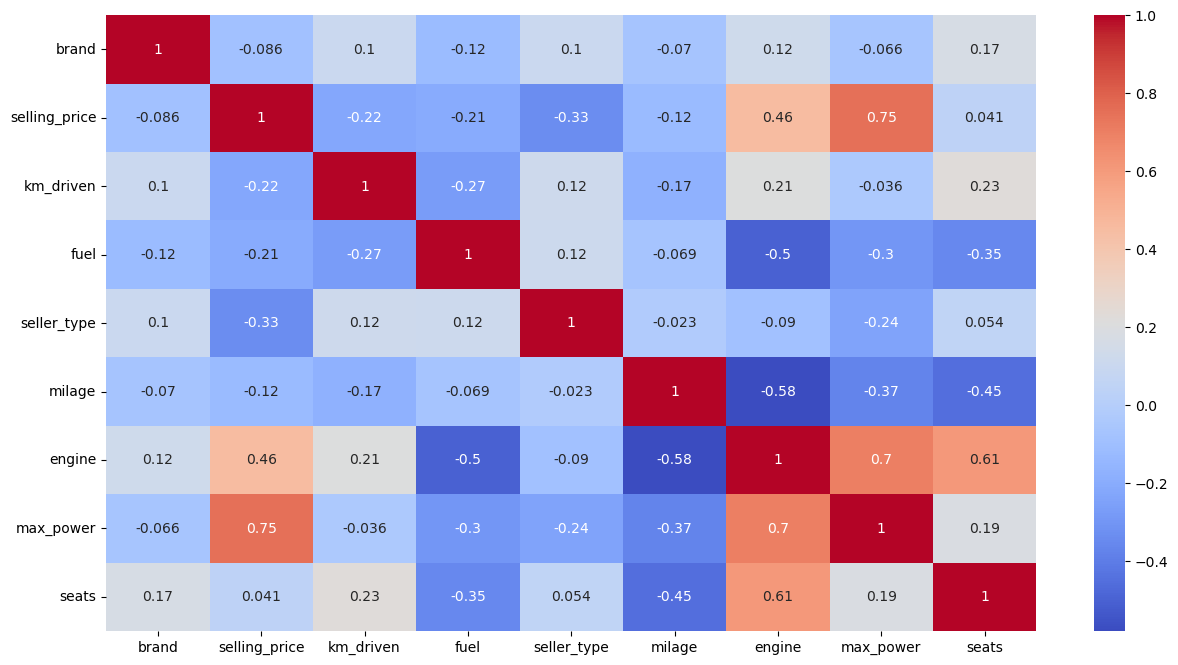

In [402]:
plt.figure(figsize = (15,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm") # corelation matrix of the features we will take for the model (x and y )

In [403]:
X = df[['brand', 'km_driven', 'fuel', 'seller_type', 'milage', 'engine', 'max_power', 'seats']]
y = df['selling_price'] #feature engineering the data x are the features we use to get the y where y is the selling price of cars

In [404]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42) # Splitting the data into train set and test set

In [405]:
X_train[['brand', 'km_driven', 'fuel', 'seller_type', 'milage', 'engine', 'max_power', 'seats']].isna().sum() # finding the null values in x

brand            0
km_driven        0
fuel             0
seller_type      0
milage         154
engine         154
max_power      149
seats          154
dtype: int64

In [406]:
y_train.isna().sum() #finding the null values in y

np.int64(0)

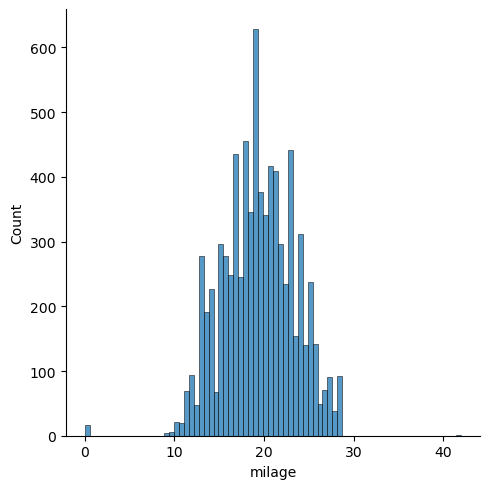

In [407]:
sns.displot(data=df, x='milage') # plotting the data

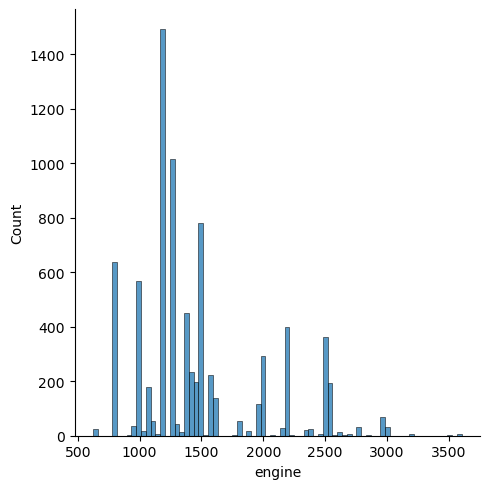

In [408]:
sns.displot(data=df, x='engine')

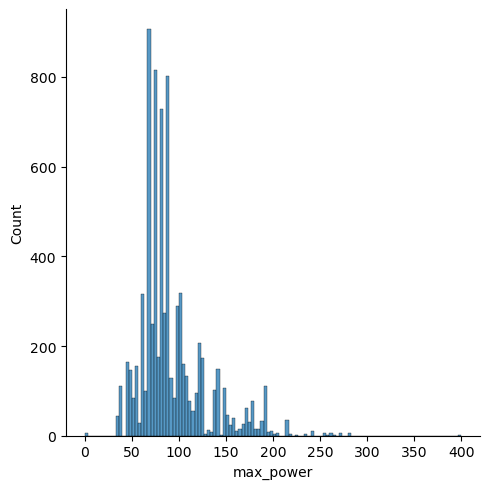

In [409]:
sns.displot(data=df, x='max_power')

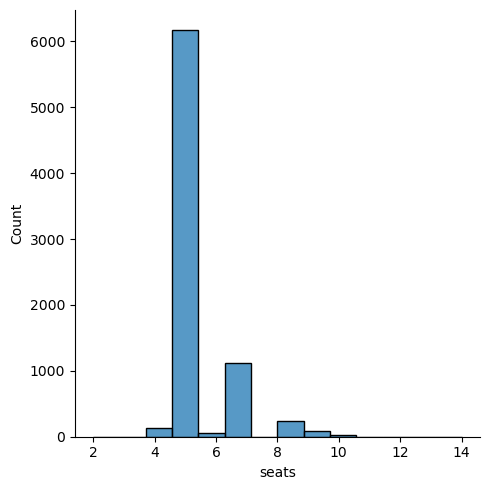

In [410]:
sns.displot(data=df, x='seats')

In [411]:
X_train['milage'].fillna(X_train['milage'].median(), inplace=True)
X_train['engine'].fillna(X_train['engine'].median(), inplace=True)
X_train['seats'].fillna(X_train['seats'].median(), inplace=True)
X_train['max_power'].fillna(X_train['max_power'].median(), inplace=True) # filling the null data in the x of the trainset with the median

C:\Users\aashu\AppData\Local\Temp\ipykernel_24276\4222864031.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['milage'].fillna(X_train['milage'].median(), inplace=True)
C:\Users\aashu\AppData\Local\Temp\ipykernel_24276\4222864031.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [412]:
X_train['seats'].isna().sum()

np.int64(0)

In [413]:
X_train[['brand', 'km_driven', 'fuel', 'seller_type', 'milage', 'engine', 'max_power', 'seats']].isna().sum() # checking if the x train dataset has any null values. it does not. the values have been imputed.

brand          0
km_driven      0
fuel           0
seller_type    0
milage         0
engine         0
max_power      0
seats          0
dtype: int64

In [414]:
X_test['milage'].fillna(X_test['milage'].median(), inplace=True)
X_test['engine'].fillna(X_test['engine'].median(), inplace=True)
X_test['seats'].fillna(X_test['seats'].median(), inplace=True)
X_test['max_power'].fillna(X_test['max_power'].median(), inplace=True) 

# filling data in test set

C:\Users\aashu\AppData\Local\Temp\ipykernel_24276\2144099587.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test['milage'].fillna(X_test['milage'].median(), inplace=True)
C:\Users\aashu\AppData\Local\Temp\ipykernel_24276\2144099587.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [415]:
X_test[['brand', 'km_driven', 'fuel', 'seller_type', 'milage', 'engine', 'max_power', 'seats']].isna().sum() # checking if the test set has null values.

brand          0
km_driven      0
fuel           0
seller_type    0
milage         0
engine         0
max_power      0
seats          0
dtype: int64

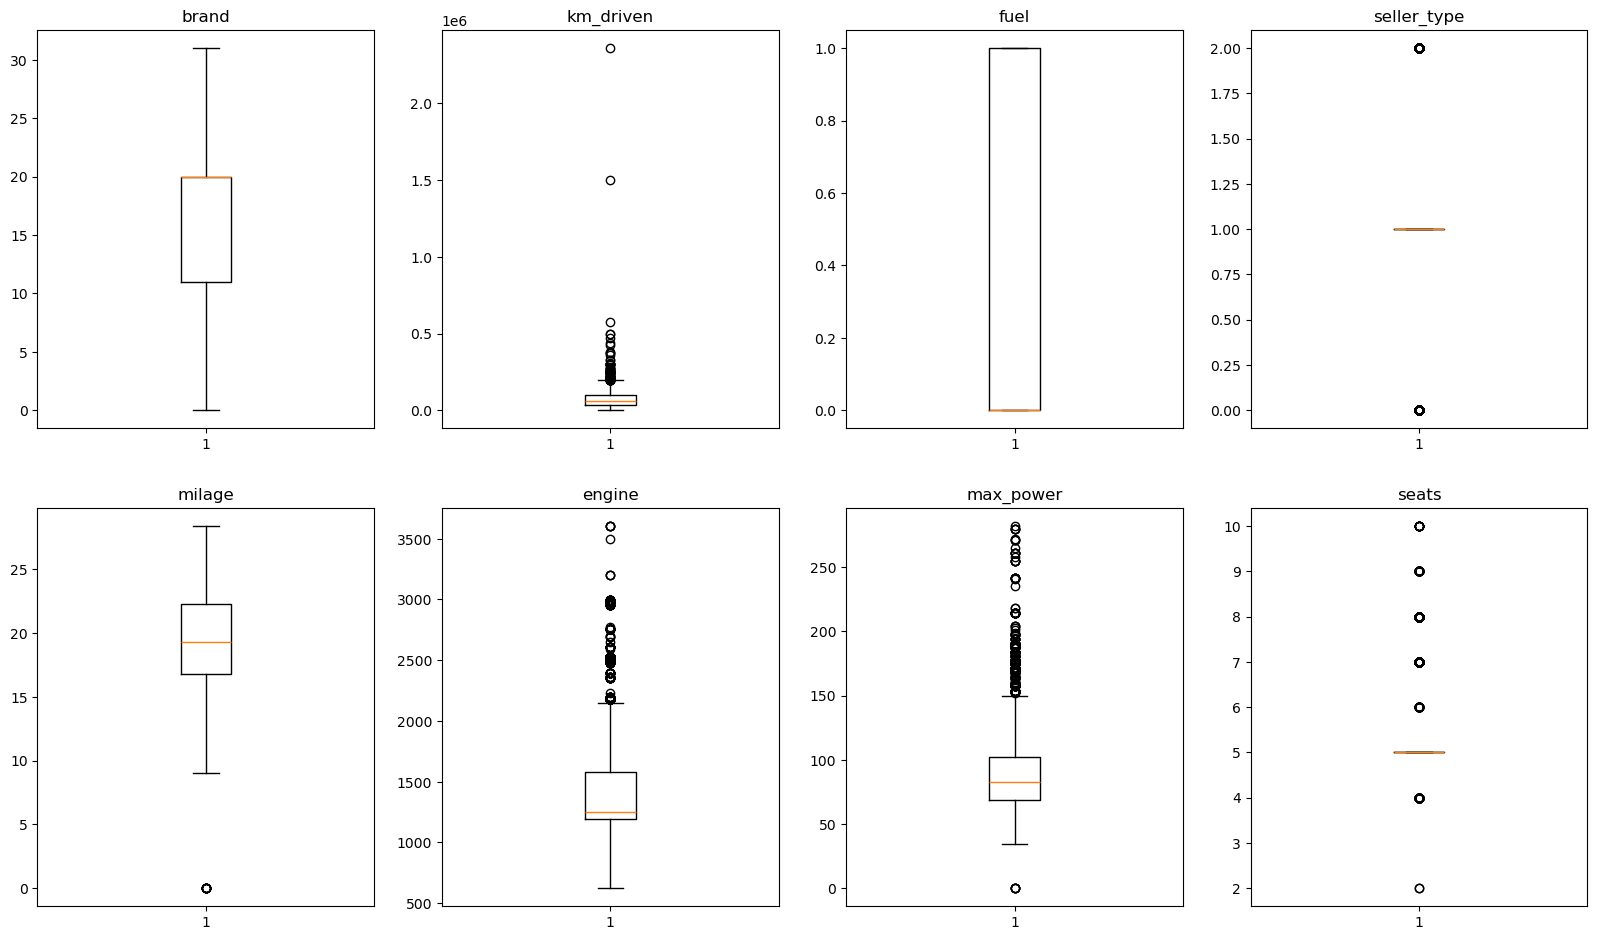

In [416]:
col_dict = {'brand':1,'km_driven':2, 'fuel':3, 'seller_type':4, 'milage':5, 'engine':6, 'max_power':7, 'seats':8}

# Detect outliers in each variable using box plots.
plt.figure(figsize=(20,30))

for variable,i in col_dict.items():
                     plt.subplot(5,4,i)
                     plt.boxplot(X_train[variable])
                     plt.title(variable)

plt.show()

In [417]:
def outlier_count(col, data = X_train):
    
    # calculating the 25% quatile and 75% quatile
    q75, q25 = np.percentile(data[col], [75, 25])
    
    # calculate the inter quatile
    iqr = q75 - q25
    
    # min_val and max_val
    min_val = q25 - (iqr*1.5)
    max_val = q75 + (iqr*1.5)
    
    # counting the number of outliers, which are the data that are less than min_val or more than max_val which was calculated above.
    outlier_count = len(np.where((data[col] > max_val) | (data[col] < min_val))[0])
    
    # calculating the percentage of the outliers.
    outlier_percent = round(outlier_count/len(data[col])*100, 2)
    
    if(outlier_count > 0):
        print("\n"+15*'-' + col + 15*'-'+"\n")
        print('Number of outliers: {}'.format(outlier_count))
        print('Percent of data that is outlier: {}%'.format(outlier_percent))

In [418]:
for col in X_train.columns: #lets check the percentage of outliers in each columns.
    outlier_count(col)


---------------km_driven---------------

Number of outliers: 102
Percent of data that is outlier: 1.82%

---------------seller_type---------------

Number of outliers: 944
Percent of data that is outlier: 16.8%

---------------milage---------------

Number of outliers: 14
Percent of data that is outlier: 0.25%

---------------engine---------------

Number of outliers: 836
Percent of data that is outlier: 14.88%

---------------max_power---------------

Number of outliers: 409
Percent of data that is outlier: 7.28%

---------------seats---------------

Number of outliers: 1158
Percent of data that is outlier: 20.61%


In [419]:
# from sklearn.preprocessing import StandardScaler

# # feature scaling the data
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test  = scaler.transform(X_test)

In [420]:
from sklearn.preprocessing import MinMaxScaler

# Scale X
scaler_X = MinMaxScaler()
X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)

# Scale y
scaler_y = MinMaxScaler()
y_train = scaler_y.fit_transform(y_train.to_numpy().reshape(-1,1)).flatten()
y_test  = scaler_y.transform(y_test.to_numpy().reshape(-1,1)).flatten()

In [421]:
print("Shape of x_train: ", X_train.shape) #printing after scaling
print("Shape of x_test: ", X_test.shape)
print("Shape of y_train: ", y_train.shape)
print("Shape of y_test: ", y_test.shape)

Shape of x_train:  (5619, 8)
Shape of x_test:  (2409, 8)
Shape of y_train:  (5619,)
Shape of y_test:  (2409,)


In [422]:
# from sklearn.linear_model import LinearRegression  #calculating the MSE and r2 using the linear regression model
# from sklearn.metrics import mean_squared_error, r2_score

# lr = LinearRegression()
# lr.fit(x_train, y_train)
# yhat = lr.predict(x_test)

# print("MSE: ", mean_squared_error(y_test, yhat))
# print("r2: ", r2_score(y_test, yhat))

In [423]:
#!pip install mlflow

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
import mlflow

class LinearRegression(object):
    
    kfold = KFold(n_splits=3)
    
    def __init__(self, regularization, lr=0.001, method='batch', num_epochs=500, batch_size=50,
                 cv=kfold, init_method='zeros', use_momentum=False, momentum=0.9):
        self.lr             = lr
        self.num_epochs     = num_epochs
        self.batch_size     = batch_size
        self.method         = method
        self.cv             = cv
        self.regularization = regularization
        
        self.init_method    = init_method.lower()
        self.use_momentum   = use_momentum
        self.momentum       = momentum
        self.velocity       = None  # for momentum
    
    def mse(self, ytrue, ypred):
        return np.mean((ypred - ytrue)**2)
    
    def r2(self, ytrue, ypred):
        ss_res = np.sum((ytrue - ypred)**2)
        ss_tot = np.sum((ytrue - np.mean(ytrue))**2)
        return 1 - (ss_res / ss_tot)
    
    def _initialize_weights(self, n_features):
        if self.init_method == 'xavier':
            limit = np.sqrt(1 / n_features)
            return np.random.uniform(-limit, limit, size=n_features)
        elif self.init_method == 'zeros':
            return np.zeros(n_features)
        else:
            raise ValueError("init_method must be either 'zeros' or 'xavier'")
    
    def fit(self, X_train, y_train):
        self.kfold_scores = []
        self.val_loss_old = np.inf

        for fold, (train_idx, val_idx) in enumerate(self.cv.split(X_train)):
            
            X_cross_train = X_train[train_idx]
            y_cross_train = y_train[train_idx]
            X_cross_val   = X_train[val_idx]
            y_cross_val   = y_train[val_idx]
            
            # Initialize weights
            self.theta = self._initialize_weights(X_cross_train.shape[1])
            
            # Initialize velocity for momentum
            if self.use_momentum:
                self.velocity = np.zeros_like(self.theta)
            
            with mlflow.start_run(run_name=f"Fold-{fold}", nested=True):
                
                params = {"method": self.method, "lr": self.lr, "reg": type(self).__name__,
                          "init_method": self.init_method, "use_momentum": self.use_momentum,
                          "momentum": self.momentum}
                mlflow.log_params(params=params)
                
                for epoch in range(self.num_epochs):
                    perm = np.random.permutation(X_cross_train.shape[0])
                    X_cross_train = X_cross_train[perm]
                    y_cross_train = y_cross_train[perm]
                    
                    if self.method == 'sto':
                        for batch_idx in range(X_cross_train.shape[0]):
                            X_batch = X_cross_train[batch_idx].reshape(1, -1)
                            y_batch = y_cross_train[batch_idx]
                            train_loss = self._train(X_batch, y_batch)
                    elif self.method == 'mini':
                        for batch_idx in range(0, X_cross_train.shape[0], self.batch_size):
                            X_batch = X_cross_train[batch_idx:batch_idx+self.batch_size, :]
                            y_batch = y_cross_train[batch_idx:batch_idx+self.batch_size]
                            train_loss = self._train(X_batch, y_batch)
                    else:
                        X_batch = X_cross_train
                        y_batch = y_cross_train
                        train_loss = self._train(X_batch, y_batch)

                    mlflow.log_metric(key="train_loss", value=train_loss, step=epoch)

                    yhat_val = self.predict(X_cross_val)
                    val_loss_new = self.mse(y_cross_val, yhat_val)
                    mlflow.log_metric(key="val_loss", value=val_loss_new, step=epoch)
                    
                    if np.allclose(val_loss_new, self.val_loss_old):
                        break
                    self.val_loss_old = val_loss_new
            
                self.kfold_scores.append(val_loss_new)
                print(f"Fold {fold}: {val_loss_new}")
                    
    def _train(self, X, y):
        X = X.to_numpy() if hasattr(X, "to_numpy") else X
        y = y.to_numpy() if hasattr(y, "to_numpy") else y
        yhat = self.predict(X)
        m = X.shape[0]
        grad = (1/m) * X.T @ (yhat - y) + self.regularization.derivation(self.theta)
        grad[0]=0 # changes
        if self.use_momentum:
            self.velocity = self.momentum * self.velocity + self.lr * grad
            self.theta = self.theta - self.velocity
        else:
            self.theta = self.theta - self.lr * grad
        return self.mse(y, yhat)
    
    def predict(self, X):
        X = X.to_numpy() if hasattr(X, "to_numpy") else X
        return X @ self.theta
    
    def _coef(self):
        return self.theta[1:]
    
    def _bias(self):
        return self.theta[0]


In [425]:
class LassoPenalty:
    
    def __init__(self, l):
        self.l = l # lambda value
        
    def __call__(self, theta): #__call__ allows us to call class as method
        return self.l * np.sum(np.abs(theta))
        
    def derivation(self, theta):
        return self.l * np.sign(theta)
    
class RidgePenalty:
    
    def __init__(self, l):
        self.l = l
        
    def __call__(self, theta): #__call__ allows us to call class as method
        return self.l * np.sum(np.square(theta))
        
    def derivation(self, theta):
        return self.l * 2 * theta
    
class ElasticPenalty:
    
    def __init__(self, l = 0.1, l_ratio = 0.5):
        self.l = l 
        self.l_ratio = l_ratio

    def __call__(self, theta):  #__call__ allows us to call class as method
        l1_contribution = self.l_ratio * self.l * np.sum(np.abs(theta))
        l2_contribution = (1 - self.l_ratio) * self.l * 0.5 * np.sum(np.square(theta))
        return (l1_contribution + l2_contribution)

    def derivation(self, theta):
        l1_derivation = self.l * self.l_ratio * np.sign(theta)
        l2_derivation = self.l * (1 - self.l_ratio) * theta
        return (l1_derivation + l2_derivation)
    
class NoPenalty:
    def __call__(self, theta):
        return 0
    def derivation(self, theta):
        return np.zeros_like(theta)
    
class Lasso(LinearRegression):
    def __init__(self, method='batch', lr=0.001, l=0.1, init_method='zeros', use_momentum=False, momentum=0.9):
        regularization = LassoPenalty(l)
        super().__init__(regularization, lr, method, init_method=init_method,
                         use_momentum=use_momentum, momentum=momentum)

class Ridge(LinearRegression):
    def __init__(self, method='batch', lr=0.001, l=0.1, init_method='zeros', use_momentum=False, momentum=0.9):
        regularization = RidgePenalty(l)
        super().__init__(regularization, lr, method, init_method=init_method,
                         use_momentum=use_momentum, momentum=momentum)

class ElasticNet(LinearRegression):
    def __init__(self, method='batch', lr=0.001, l=0.1, l_ratio=0.5, init_method='zeros',
                 use_momentum=False, momentum=0.9):
        regularization = ElasticPenalty(l, l_ratio)
        super().__init__(regularization, lr, method, init_method=init_method,
                         use_momentum=use_momentum, momentum=momentum)



In [426]:
#helper function for looping classnames
import sys

def str_to_class(classname):
    return getattr(sys.modules[__name__], classname)

In [427]:
# Convert y to 1D numpy arrays (no .reshape!)
y_train = np.array(y_train, dtype=np.float64)
y_test = np.array(y_test, dtype=np.float64)

In [428]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import mlflow

regs = ["Ridge", "Lasso", "ElasticNet"]

for reg in regs:
    params = {
        "method": "batch",
        "lr": 0.005,
        "l": 0.01,
        "init_method": "xavier",
        "use_momentum": True,
        "momentum": 0.9
    }
    if reg == "ElasticNet":
        params["l_ratio"] = 0.5

    type_of_regression = str_to_class(reg)
    model = type_of_regression(**params)

    with mlflow.start_run(run_name=f"{reg}_batch_lr-{params['lr']}"):
        model.fit(X_train, y_train)
        yhat = model.predict(X_test)

        # Metrics
        mse = model.mse(y_test, yhat)
        r2 = model.r2(y_test, yhat)
        mlflow.log_metric("test_mse", mse)
        mlflow.log_metric("test_r2", r2)

        # Parameters
        mlflow.log_param("regression_type", reg)
        mlflow.log_params(params)

        

Fold 0: 0.007667338703794864
🏃 View run Fold-0 at: http://localhost:9000/#/experiments/688322752433676532/runs/00a862f0c05746bbb6d32b90f27c53f2
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Fold 1: 0.009339825164063531
🏃 View run Fold-1 at: http://localhost:9000/#/experiments/688322752433676532/runs/c199c7182ede44bc9cb74817bad85b66
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Fold 2: 0.006255774407716716
🏃 View run Fold-2 at: http://localhost:9000/#/experiments/688322752433676532/runs/4837ff557f5044c181c131c63fea84d7
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
🏃 View run Ridge_batch_lr-0.005 at: http://localhost:9000/#/experiments/688322752433676532/runs/2333715a0e984f17ada4efdbe636cd57
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Fold 0: 0.008931166799443134
🏃 View run Fold-0 at: http://localhost:9000/#/experiments/688322752433676532/runs/9e9ce19ea4944fc7aba2

In [431]:
# # Feature importance
# feature_names = X_train.columns if isinstance(X_train, pd.DataFrame) else [f"f{i}" for i in range(X_train.shape[1])]
# feature_importance = pd.Series(np.abs(model.theta), index=feature_names)
# feature_importance = feature_importance.sort_values(ascending=False)

# # --- Feature Importance Plot ---
# plt.figure(figsize=(8,5))
# sns.barplot(x=feature_importance.values, y=feature_importance.index)
# plt.title(f"{reg} Feature Importance")
# plt.xlabel("Absolute Coefficient Value")
# plt.ylabel("feature")
# plt.tight_layout()
# plt.show()  # Show in notebook
# mlflow.log_figure(plt.gcf(), "feature_importance.png")
# plt.close()

# # --- Residual Plot ---
# residuals = y_test - yhat
# plt.figure(figsize=(6,4))
# sns.scatterplot(x=yhat, y=residuals)
# plt.axhline(0, color='red', linestyle='--')
# plt.xlabel("Predicted")
# plt.ylabel("Residuals")
# plt.title(f"{reg} Residual Plot")
# plt.tight_layout()
# plt.show()  # Show in notebook
# mlflow.log_figure(plt.gcf(), "residual_plot.png")
# plt.close()

# # --- Predicted vs Actual ---
# plt.figure(figsize=(6,6))
# sns.scatterplot(x=y_test, y=yhat)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
# plt.xlabel("Actual")
# plt.ylabel("Predicted")
# plt.title(f"{reg} Predicted vs Actual")
# plt.tight_layout()
# plt.show()  # Show in notebook
# mlflow.log_figure(plt.gcf(), "predicted_vs_actual.png")
# plt.close()


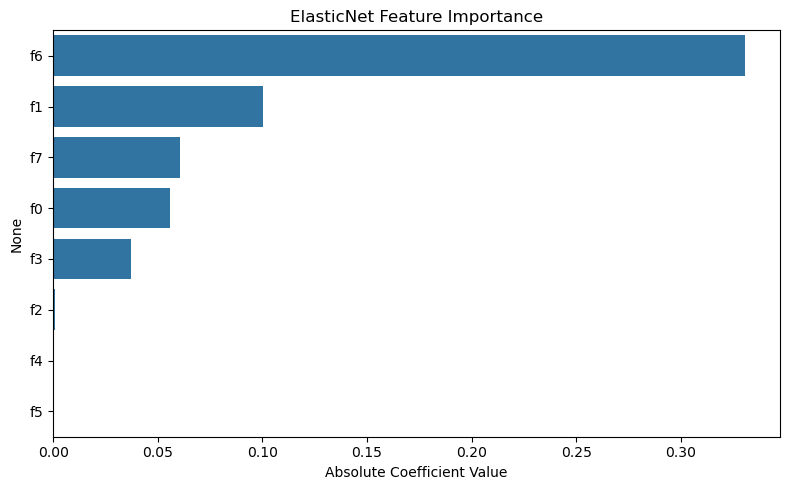

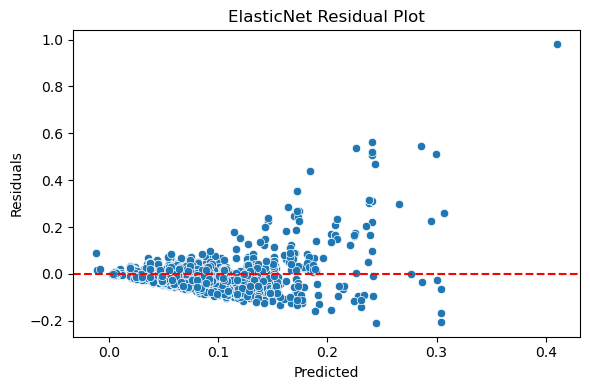

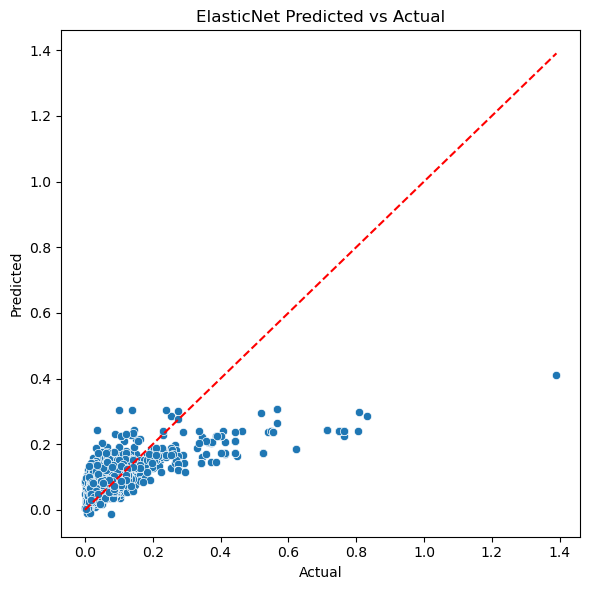

In [432]:

# --- Feature Importance Plot ---
plt.figure(figsize=(8,5))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title(f"{reg} Feature Importance")
plt.xlabel("Absolute Coefficient Value")
plt.tight_layout()
plt.show()  # Show in notebook
mlflow.log_figure(plt.gcf(), "feature_importance.png")
plt.close()

# --- Residual Plot ---
residuals = y_test - yhat
plt.figure(figsize=(6,4))
sns.scatterplot(x=yhat, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title(f"{reg} Residual Plot")
plt.tight_layout()
plt.show()  # Show in notebook
mlflow.log_figure(plt.gcf(), "residual_plot.png")
plt.close()

# --- Predicted vs Actual ---
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=yhat)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"{reg} Predicted vs Actual")
plt.tight_layout()
plt.show()  # Show in notebook
mlflow.log_figure(plt.gcf(), "predicted_vs_actual.png")
plt.close()


In [433]:
import itertools

# -----------------------------
# Parameter options
# -----------------------------
models = ["Normal", "Lasso", "Ridge", "ElasticNet"]  # model type
degrees = [1, 2]                                     # polynomial degrees
momentums = [False, True]                            # use momentum or not
methods = ["sto", "mini", "batch"]                  # training methods
inits = ["zeros", "xavier"]                          # weight initialization
lrs = [0.01, 0.001, 0.0001]                         # learning rates

# Optional: regularization parameters for Lasso, Ridge, ElasticNet
l_values = [0.01]            # you can expand if needed
l_ratios = [0.5]             # for ElasticNet

# -----------------------------
# Generate all experiment combinations
# -----------------------------
experiment_list = []

for m, d, mom, meth, init, lr in itertools.product(models, degrees, momentums, methods, inits, lrs):
    exp = {
        "model_type": m,
        "degree": d,
        "use_momentum": mom,
        "method": meth,
        "init_method": init,
        "lr": lr
    }
    # Add regularization for applicable models
    if m in ["Lasso", "Ridge"]:
        exp["l"] = l_values[0]
    if m == "ElasticNet":
        exp["l"] = l_values[0]
        exp["l_ratio"] = l_ratios[0]
    
    experiment_list.append(exp)

# -----------------------------
# Summary
# -----------------------------
print(f"Total experiments to run: {len(experiment_list)}")  # 288
experiment_list[:5]  # preview first 5 experiments


Total experiments to run: 288


[{'model_type': 'Normal',
  'degree': 1,
  'use_momentum': False,
  'method': 'sto',
  'init_method': 'zeros',
  'lr': 0.01},
 {'model_type': 'Normal',
  'degree': 1,
  'use_momentum': False,
  'method': 'sto',
  'init_method': 'zeros',
  'lr': 0.001},
 {'model_type': 'Normal',
  'degree': 1,
  'use_momentum': False,
  'method': 'sto',
  'init_method': 'zeros',
  'lr': 0.0001},
 {'model_type': 'Normal',
  'degree': 1,
  'use_momentum': False,
  'method': 'sto',
  'init_method': 'xavier',
  'lr': 0.01},
 {'model_type': 'Normal',
  'degree': 1,
  'use_momentum': False,
  'method': 'sto',
  'init_method': 'xavier',
  'lr': 0.001}]

In [434]:
def run_experiment(model_type="Ridge", degree=1, use_momentum=False,
                   method='batch', init_method='xavier', lr=0.01, l=0.01, l_ratio=0.5):
    """
    Run a single experiment with all options and log to MLflow.
    """

    # -----------------------
    # Convert to DataFrame if needed
    # -----------------------
    import pandas as pd
    if not isinstance(X_train, pd.DataFrame):
        X_train_df = pd.DataFrame(X_train, columns=[f"x{i}" for i in range(X_train.shape[1])])
        X_test_df  = pd.DataFrame(X_test, columns=[f"x{i}" for i in range(X_test.shape[1])])
    else:
        X_train_df, X_test_df = X_train.copy(), X_test.copy()

    # -----------------------
    # Polynomial transform
    # -----------------------
    if degree > 1:
        from sklearn.preprocessing import PolynomialFeatures
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_train_exp = poly.fit_transform(X_train_df)
        X_test_exp  = poly.transform(X_test_df)
        feature_names = poly.get_feature_names_out(X_train_df.columns)
    else:
        X_train_exp, X_test_exp = X_train_df.values, X_test_df.values
        feature_names = X_train_df.columns

    # -----------------------
    # Select and initialize model
    # -----------------------
    if model_type == "Ridge":
        model = Ridge(method=method, lr=lr, l=l, init_method=init_method, use_momentum=use_momentum)
    elif model_type == "Lasso":
        model = Lasso(method=method, lr=lr, l=l, init_method=init_method, use_momentum=use_momentum)
    elif model_type == "ElasticNet":
        model = ElasticNet(method=method, lr=lr, l=l, l_ratio=l_ratio, init_method=init_method, use_momentum=use_momentum)
    else:
        model = LinearRegression(regularization=NoPenalty(), method=method, lr=lr, init_method=init_method, use_momentum=use_momentum)

    # -----------------------
    # MLflow logging
    # -----------------------
    import mlflow
    run_name = f"{model_type}_deg{degree}_{method}_{init_method}_lr{lr}_mom{use_momentum}"
    with mlflow.start_run(run_name=run_name):
        # Fit & predict
        model.fit(X_train_exp, y_train)
        y_pred = model.predict(X_test_exp)

        # Metrics
        mse = model.mse(y_test, y_pred)
        r2  = model.r2(y_test, y_pred)
        mlflow.log_params({
            "model": model_type,
            "degree": degree,
            "use_momentum": use_momentum,
            "method": method,
            "init_method": init_method,
            "lr": lr
        })
        mlflow.log_metric("test_mse", mse)
        mlflow.log_metric("test_r2", r2)

        # Feature importance
        import matplotlib.pyplot as plt
        import pandas as pd
        coef = np.abs(model.theta)
        fi = pd.Series(coef, index=feature_names).sort_values(ascending=False)
        plt.figure(figsize=(8,5))
        fi.plot(kind='bar')
        plt.title(f"Feature Importance ({run_name})")
        plt.show()

        # Save and log figure
        fig_path = f"feature_importance_{run_name}.png"
        plt.savefig(fig_path)
        mlflow.log_artifact(fig_path)
        plt.close()

    return mse, r2


Fold 0: 0.011655151451199794
🏃 View run Fold-0 at: http://localhost:9000/#/experiments/688322752433676532/runs/5f5475ae23574bc39ecf32f3759781f8
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Fold 1: 0.010163057043186107
🏃 View run Fold-1 at: http://localhost:9000/#/experiments/688322752433676532/runs/8c49289610ed44d5a4e44f7ae28c6fe0
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Fold 2: 0.007990976954397641
🏃 View run Fold-2 at: http://localhost:9000/#/experiments/688322752433676532/runs/cccaae39ae8b45118d2fae5d5aeb0e6f
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532


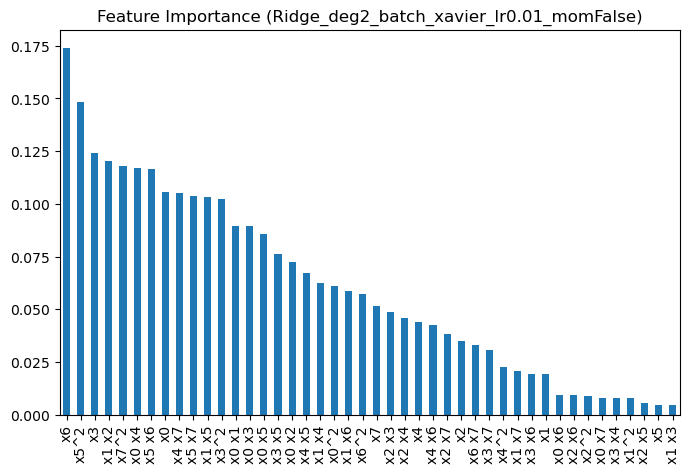

🏃 View run Ridge_deg2_batch_xavier_lr0.01_momFalse at: http://localhost:9000/#/experiments/688322752433676532/runs/2958097bd75b49908118c87cd140ea75
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Ridge Poly - mse: 0.0094, r2: 0.2732
Fold 0: 0.009278724493147431
🏃 View run Fold-0 at: http://localhost:9000/#/experiments/688322752433676532/runs/c3118dc3abb745b7b6dd2e082a472d45
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Fold 1: 0.008218442781831174
🏃 View run Fold-1 at: http://localhost:9000/#/experiments/688322752433676532/runs/61eadc90ea9f41228751fbd34508de9a
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Fold 2: 0.007916795604298263
🏃 View run Fold-2 at: http://localhost:9000/#/experiments/688322752433676532/runs/8486446a263d4036b29eec3659a32a46
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532


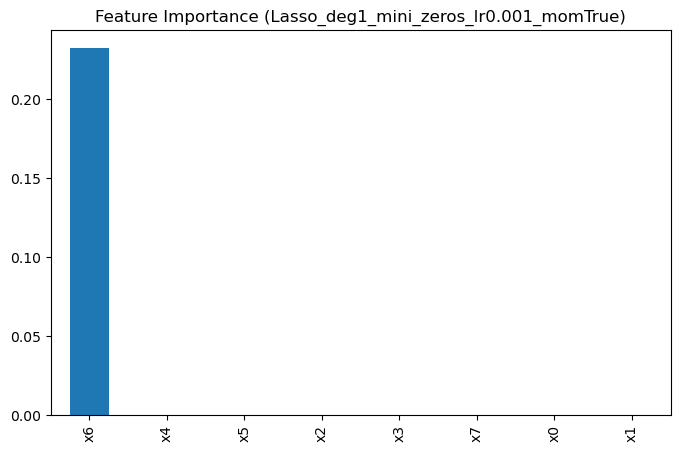

🏃 View run Lasso_deg1_mini_zeros_lr0.001_momTrue at: http://localhost:9000/#/experiments/688322752433676532/runs/6b51edaed212423ea87749bab2be3674
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Lasso Normal - mse: 0.0089, r2: 0.3132
Fold 0: 0.007911299313377229
🏃 View run Fold-0 at: http://localhost:9000/#/experiments/688322752433676532/runs/10bd91a2f6e44cc98764137c6c4e96a4
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Fold 1: 0.006884675459554824
🏃 View run Fold-1 at: http://localhost:9000/#/experiments/688322752433676532/runs/7f437a4c3b814d02907c67c1ce728533
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Fold 2: 0.006611894057716941
🏃 View run Fold-2 at: http://localhost:9000/#/experiments/688322752433676532/runs/0da53ae10fae4ba4807b6b6a88bd3bb7
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532


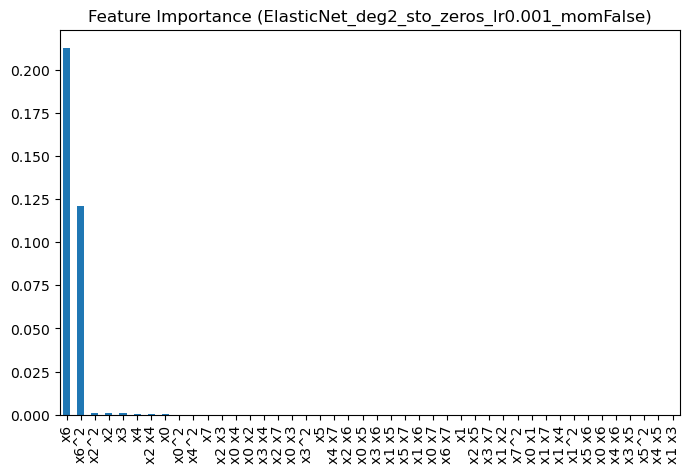

🏃 View run ElasticNet_deg2_sto_zeros_lr0.001_momFalse at: http://localhost:9000/#/experiments/688322752433676532/runs/52eebb2f0e954aa4a1712db1accb3612
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
ElasticNet Poly - mse: 0.0075, r2: 0.4238
Fold 0: 0.006813983902059652
🏃 View run Fold-0 at: http://localhost:9000/#/experiments/688322752433676532/runs/96870e237de34061adfc67bb3037c3df
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Fold 1: 0.005861677610830771
🏃 View run Fold-1 at: http://localhost:9000/#/experiments/688322752433676532/runs/786a846f551b40e68b58b91df7e35e83
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Fold 2: 0.0058025259604558965
🏃 View run Fold-2 at: http://localhost:9000/#/experiments/688322752433676532/runs/c6609ec3b65441e5afba1e2b63e06446
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532


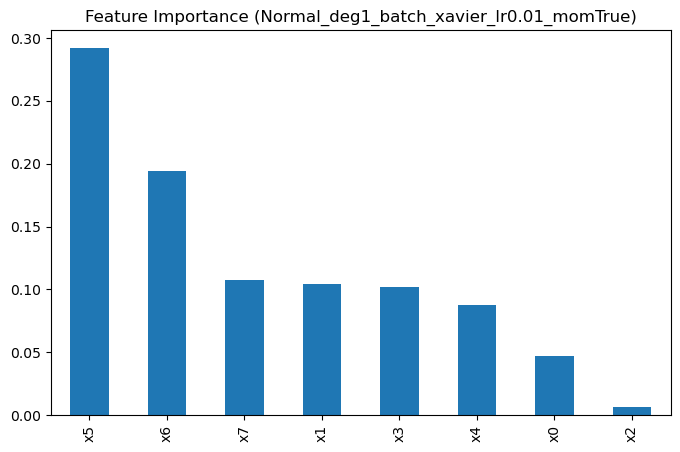

🏃 View run Normal_deg1_batch_xavier_lr0.01_momTrue at: http://localhost:9000/#/experiments/688322752433676532/runs/3fcdda24f6054ecb814268158bb5b82a
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Normal Linear - mse: 0.0067, r2: 0.4847
Fold 0: 0.007309168288781026
🏃 View run Fold-0 at: http://localhost:9000/#/experiments/688322752433676532/runs/43751c258b864f27b1fed4caf36ccf9b
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Fold 1: 0.006402867521271296
🏃 View run Fold-1 at: http://localhost:9000/#/experiments/688322752433676532/runs/b5a1714b1dd947a4966a70aac204e3d0
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Fold 2: 0.006134317773014756
🏃 View run Fold-2 at: http://localhost:9000/#/experiments/688322752433676532/runs/dbfd9931cc07479d9ff634668ac18200
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532


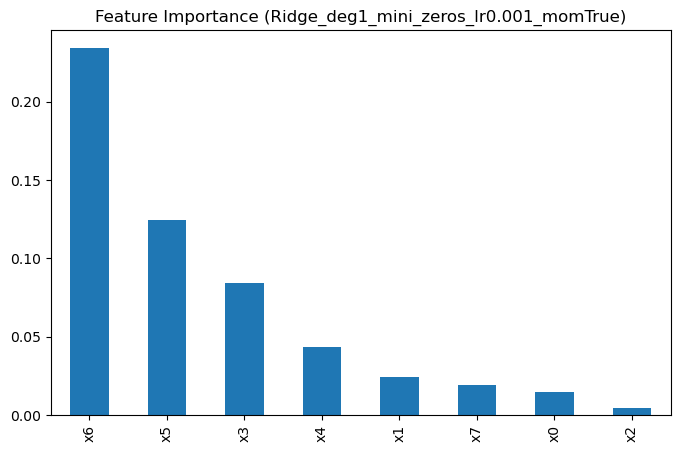

🏃 View run Ridge_deg1_mini_zeros_lr0.001_momTrue at: http://localhost:9000/#/experiments/688322752433676532/runs/43d12b713e5349458267f4791c427e0b
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Ridge Normal - mse: 0.0071, r2: 0.4513
Fold 0: 0.010662669661713354
🏃 View run Fold-0 at: http://localhost:9000/#/experiments/688322752433676532/runs/9f085724097b4dbbb21b1ae93f4dd62c
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Fold 1: 0.007213051085893527
🏃 View run Fold-1 at: http://localhost:9000/#/experiments/688322752433676532/runs/8aefcfcca63d4b46ba2c6892a8482184
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Fold 2: 0.01007356840573905
🏃 View run Fold-2 at: http://localhost:9000/#/experiments/688322752433676532/runs/6dc6961a9bec447d87049d50867b5dc3
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532


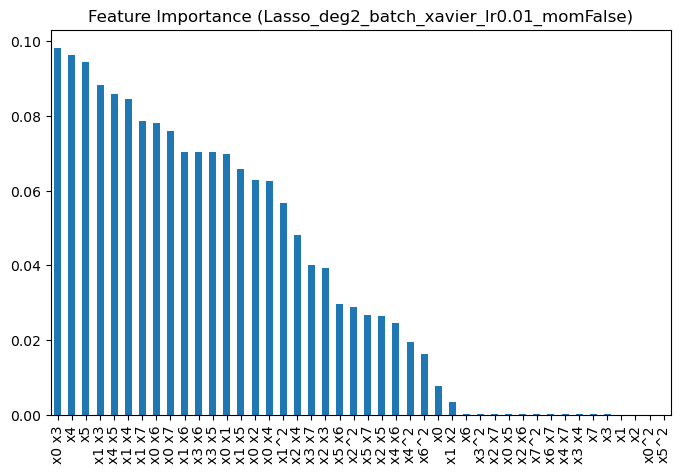

🏃 View run Lasso_deg2_batch_xavier_lr0.01_momFalse at: http://localhost:9000/#/experiments/688322752433676532/runs/b53dd7679e30442fb5bf9bc7e90fe9f5
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Lasso Poly - mse: 0.0112, r2: 0.1392


In [439]:
import mlflow

# 1. Ridge regression with polynomial features, batch method, xavier init, lr=0.01, momentum off
mlflow.end_run()
mse, r2 = run_experiment(
    model_type="Ridge",
    degree=2,
    method='batch',
    init_method='xavier',
    lr=0.01,
    use_momentum=False
)
print(f"Ridge Poly - mse: {mse:.4f}, r2: {r2:.4f}")

# 2. Lasso, normal features, mini-batch, zeros init, lr=0.001, momentum on
mlflow.end_run()
mse, r2 = run_experiment(
    model_type="Lasso",
    degree=1,
    method='mini',
    init_method='zeros',
    lr=0.001,
    use_momentum=True
)
print(f"Lasso Normal - mse: {mse:.4f}, r2: {r2:.4f}")

# 3. ElasticNet, polynomial features, stochastic method, zeros init, lr=0.001, momentum off
mlflow.end_run()
mse, r2 = run_experiment(
    model_type="ElasticNet",
    degree=2,
    method='sto',
    init_method='zeros',
    lr=0.001,
    use_momentum=False
)
print(f"ElasticNet Poly - mse: {mse:.4f}, r2: {r2:.4f}")

# 4. Normal linear regression, normal features, batch, xavier init, lr=0.01, momentum on
mlflow.end_run()
mse, r2 = run_experiment(
    model_type="Normal",
    degree=1,
    method='batch',
    init_method='xavier',
    lr=0.01,
    use_momentum=True
)
print(f"Normal Linear - mse: {mse:.4f}, r2: {r2:.4f}")

# 5. Ridge, normal features, mini-batch, zeros init, lr=0.001, momentum on
mlflow.end_run()
mse, r2 = run_experiment(
    model_type="Ridge",
    degree=1,
    method='mini',
    init_method='zeros',
    lr=0.001,
    use_momentum=True
)
print(f"Ridge Normal - mse: {mse:.4f}, r2: {r2:.4f}")

# 6. Lasso, polynomial features, batch method, xavier init, lr=0.01, momentum off
mlflow.end_run()
mse, r2 = run_experiment(
    model_type="Lasso",
    degree=2,
    method='batch',
    init_method='xavier',
    lr=0.01,
    use_momentum=False
)
print(f"Lasso Poly - mse: {mse:.4f}, r2: {r2:.4f}")

mlflow.end_run()

In [ ]:
# print(f"Ridge Poly - mse: {mse:.4f}, r2: {r2:.4f}")
# print(f"Lasso Normal - mse: {mse:.4f}, r2: {r2:.4f}")
# print(f"ElasticNet Poly - mse: {mse:.4f}, r2: {r2:.4f}")
# print(f"Normal Linear - mse: {mse:.4f}, r2: {r2:.4f}")
# print(f"Ridge Normal - mse: {mse:.4f}, r2: {r2:.4f}")
# print(f"Lasso Poly - mse: {mse:.4f}, r2: {r2:.4f}")

In [440]:
experiment_list = []

# Example hyperparameter grids
model_types = ["Normal", "Ridge", "ElasticNet"]
degrees = [1, 2]
use_momentums = [True, False]
methods = ["sto", "mini", "batch"]
init_methods = ["zeros", "xavier"]
lrs = [0.01, 0.001, 0.0001]
l_values = [0.01, 0.1]        # for Ridge/ElasticNet
l_ratios = [0.5, 0.7]         # for ElasticNet

# Create all combinations
for model_type in model_types:
    for degree in degrees:
        for use_momentum in use_momentums:
            for method in methods:
                for init_method in init_methods:
                    for lr in lrs:
                        # Basic params
                        params = {
                            "model_type": model_type,
                            "degree": degree,
                            "use_momentum": use_momentum,
                            "method": method,
                            "init_method": init_method,
                            "lr": lr,
                        }

                        # Add regularization params for specific models
                        if model_type in ["Ridge", "ElasticNet"]:
                            for l in l_values:
                                params_copy = params.copy()
                                params_copy["l"] = l
                                if model_type == "ElasticNet":
                                    for l_ratio in l_ratios:
                                        params_copy2 = params_copy.copy()
                                        params_copy2["l_ratio"] = l_ratio
                                        experiment_list.append(params_copy2)
                                else:
                                    experiment_list.append(params_copy)
                        else:
                            experiment_list.append(params)


In [441]:
len(experiment_list)

504

In [461]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_feature_importance(feature_importance):
    """
    feature_importance: pandas Series or dict of feature:importance
    """
    if isinstance(feature_importance, dict):
        feature_importance = pd.Series(feature_importance)
    
    feature_importance = feature_importance.sort_values(ascending=False)
    
    plt.figure(figsize=(10,6))
    plt.barh(feature_importance.index, feature_importance.values)
    plt.gca().invert_yaxis()  # highest importance on top
    plt.xlabel("Importance")
    plt.title("Feature Importance")
    plt.show()


In [ ]:
# %pip install --upgrade flask

  Using cached flask-3.1.2-py3-none-any.whl.metadata (3.2 kB)
Using cached flask-3.1.2-py3-none-any.whl (103 kB)
  Attempting uninstall: flask
    Found existing installation: Flask 3.1.0
    Uninstalling Flask-3.1.0:
      Successfully uninstalled Flask-3.1.0
Note: you may need to restart the kernel to use updated packages.


In [466]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

# #Make sure no active run is lingering
# if mlflow.active_run() is not None:
#      mlflow.end_run()
if mlflow.active_run() is not None:
    print(" Ending lingering active MLflow run")
    mlflow.end_run()
try:
    from mlflow.tracking.fluent import _active_run_stack
    _active_run_stack.clear()
except:
    pass  
   

results = []  # store all experiment results

for idx, params in enumerate(experiment_list, 1):
    run_name = f"{params['model_type']}_deg{params['degree']}_lr{params['lr']}_{params['method']}_{params['init_method']}_mom{params['use_momentum']}"
    
    try:
        with mlflow.start_run(run_name=run_name) as run:
            try:

                # Run your model training

                mse, r2 = run_experiment(**params)
                
  
                # Log parameters and metrics

                mlflow.log_params({k: v for k, v in params.items() if v is not None})
                mlflow.log_metric("mse", mse)
                mlflow.log_metric("r2", r2)
                

                # Store results

                results.append({**params, "mse": mse, "r2": r2})

                # GENERATE PLOTS 


                model = params.get('model')  # if your run_experiment returns a trained model
                X_test, y_test = params.get('X_test'), params.get('y_test')  # pass them via params

                if model is not None and X_test is not None and y_test is not None:
                    # Predicted values
                    y_pred = model.predict(X_test)
                    
                    # Actual vs Predicted
                    plt.figure(figsize=(6,6))
                    sns.scatterplot(x=y_test, y=y_pred)
                    plt.xlabel("Actual")
                    plt.ylabel("Predicted")
                    plt.title(f"Actual vs Predicted ({run_name})")
                    plt.plot([y_test.min(), y_test.max()],
                             [y_test.min(), y_test.max()], 'r--')
                    buf = io.BytesIO()
                    plt.savefig(buf, format='png')
                    buf.seek(0)
                    mlflow.log_image(buf, "actual_vs_predicted.png")
                    plt.close()

                    # Residuals
                    residuals = y_test - y_pred
                    plt.figure(figsize=(6,4))
                    sns.histplot(residuals, kde=True)
                    plt.xlabel("Residual")
                    plt.title(f"Residual Distribution ({run_name})")
                    buf = io.BytesIO()
                    plt.savefig(buf, format='png')
                    buf.seek(0)
                    mlflow.log_image(buf, "residuals.png")
                    plt.close()

                    # Feature importance (if model has it)
                    if hasattr(model, "coef_"):
                        feature_importance = pd.Series(model.coef_, index=X_test.columns)
                        plt.figure(figsize=(8,4))
                        sns.barplot(x=feature_importance, y=feature_importance.index)
                        plt.title(f"Feature Importance ({run_name})")
                        buf = io.BytesIO()
                        plt.savefig(buf, format='png')
                        buf.seek(0)
                        mlflow.log_image(buf, "feature_importance.png")
                        plt.close()

            except Exception as inner_e:
                print(f"Experiment {idx} failed during training: {inner_e}")
            
            finally:
                if mlflow.active_run() is not None:
                    mlflow.end_run()

    except Exception as outer_e:
        print(f"Could not start experiment {idx}: {outer_e}")

# Convert results to a DataFrame
results_df = pd.DataFrame(results)
print(results_df.head())


Experiment 1 failed during training: Run with UUID 524bbd1a562a472ab51b3063e0e7eb86 is already active. To start a new run, first end the current run with mlflow.end_run(). To start a nested run, call start_run with nested=True
🏃 View run Normal_deg1_lr0.01_sto_zeros_momTrue at: http://localhost:9000/#/experiments/688322752433676532/runs/524bbd1a562a472ab51b3063e0e7eb86
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Experiment 2 failed during training: Run with UUID 36bf11bb9adc4ed0a06c4572097c1c1c is already active. To start a new run, first end the current run with mlflow.end_run(). To start a nested run, call start_run with nested=True
🏃 View run Normal_deg1_lr0.001_sto_zeros_momTrue at: http://localhost:9000/#/experiments/688322752433676532/runs/36bf11bb9adc4ed0a06c4572097c1c1c
🧪 View experiment at: http://localhost:9000/#/experiments/688322752433676532
Experiment 3 failed during training: Run with UUID 07c56d70c9204792b9f8233338c91ab2 is already active

KeyboardInterrupt: 

In [ ]:
results_df = pd.DataFrame(results)
print("\n📊 Results Summary:")
print(results_df[['model_type', 'degree', 'lr', 'method', 'init_method', 'use_momentum', 'mse', 'r2']].head(10))

# Save to CSV
results_df.to_csv("experiment_results.csv", index=False)
print("\n💾 Results saved to 'experiment_results.csv'")

# Best model
if len(results_df) > 0:
    best_r2 = results_df.loc[results_df['r2'].idxmax()]
    print(f"\n🏆 Best Model:\n{best_r2[['model_type', 'degree', 'lr', 'method', 'init_method', 'use_momentum', 'mse', 'r2']]}")

In [ ]:
results_df.shape

In [ ]:
results_df.sort_values(by='r2', ascending=False).head(10)

In [ ]:
def summarize_for_debug(X_train, y_train, X_test, y_test, lr, l, num_epochs, batch_size):
    import numpy as np
    import pandas as pd

    print("=== Shapes ===")
    print(f"X_train: {X_train.shape}")
    print(f"y_train: {y_train.shape}")
    print(f"X_test: {X_test.shape}")
    print(f"y_test: {y_test.shape}")
    
    print("\n=== Basic Statistics ===")
    print("X_train (first 5 rows):")
    print(pd.DataFrame(X_train).head())
    print("\ny_train (first 10 values):")
    print(y_train[:10] if len(y_train) > 10 else y_train)
    
    print("\nX_train statistics:")
    print(pd.DataFrame(X_train).describe())
    
    print("\ny_train statistics:")
    if isinstance(y_train, np.ndarray):
        print(pd.Series(y_train).describe())
    else:
        print(y_train.describe())
    
    print("\n=== Hyperparameters ===")
    print(f"Learning rate (lr): {lr}")
    print(f"Regularization (l): {l}")
    print(f"Num epochs: {num_epochs}")
    print(f"Batch size: {batch_size}")

    print("\n=== Feature & target ranges ===")
    print(f"X_train min/max:\n{np.min(X_train, axis=0)} / {np.max(X_train, axis=0)}")
    print(f"y_train min/max: {np.min(y_train)} / {np.max(y_train)}")

summarize_for_debug(
    X_train, y_train, X_test, y_test,
    lr=0.0001, l=0.01, num_epochs=500, batch_size=50
)


In [ ]:
# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.5)
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

In [ ]:
# Plot residuals
residuals = y_test_orig - y_pred_orig
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_orig, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [ ]:
# Feature importance analysis
feature_importance = best_model.feature_importances_
sorted_idx = np.argsort(feature_importance)

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), [X.columns[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()
# numerical values of feature importance
for i in sorted_idx:
    print(f"{X.columns[i]}: {feature_importance[i]:.4f}")

In [ ]:
# Permutation importance
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(best_model, X_test_scaled, y_test, n_repeats=10, random_state=42)
sorted_idx = perm_importance.importances_mean.argsort()

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), perm_importance.importances_mean[sorted_idx])
plt.yticks(range(len(sorted_idx)), [X.columns[i] for i in sorted_idx])
plt.xlabel("Permutation Importance")
plt.title("Permutation Feature Importance")
plt.show()

In [ ]:
# Save the model and preprocessing objects for Flask app
model_data = {
    'model': best_model,
    'scaler': scaler,
    'le_dict': le_dict,
    'feature_cols': feature_cols,
    'feature_importance': feature_importance
}

with open('app/model/car_price_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("Model and preprocessing objects saved to 'car_price_model.pkl'")

In [ ]:
# Create a prediction function for demonstration
def predict_car_price(input_data, model_data):
    """
    Predict car price based on input features.
    
    Parameters:
    input_data (dict): Dictionary containing feature values
    model_data (dict): Contains model, scaler, label encoders, and feature columns
    
    Returns:
    float: Predicted car price
    """
    model = model_data['model']
    scaler = model_data['scaler']
    le_dict = model_data['le_dict']
    feature_cols = model_data['feature_cols']
    
    # Prepare input data in the correct order
    processed_data = []
    for col in feature_cols:
        if col in le_dict:  # Categorical feature
            # Handle unseen labels
            try:
                encoded_val = le_dict[col].transform([input_data[col]])[0]
            except ValueError:
                # If label not seen during training, use the first category
                encoded_val = 0
            processed_data.append(encoded_val)
        else:  # Numerical feature
            processed_data.append(input_data[col])
    
    # Convert to array and scale
    sample = np.array(processed_data).reshape(1, -1)
    sample_scaled = scaler.transform(sample)
    
    # Predict and transform back from log scale
    pred_log_price = model.predict(sample_scaled)[0]
    pred_price = np.exp(pred_log_price)
    
    return pred_price

In [ ]:
# Example prediction
example_car = {
    'year': 2018,
    'km_driven': 35000,
    'engine': 1498,
    'max_power': 110,
    'brand': 'Honda',
    'mileage': 17.0
}

predicted_price = predict_car_price(example_car, model_data)
print(f"\nPredicted price for example car: ${predicted_price:,.2f}")